# % of Bike Commuters vs Bike Network Quality (Connectivity of LTS < 2 Subnetwork)

In [5]:
%%capture
pip install osmnx

In [6]:
%%capture
pip install --pre pycen==0.1.0a4

In [7]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox
import networkx as nx
from pycen import acquire

plt.style.use('seaborn-v0_8')

city = "San Jose" ### CHANGE THIS TO TRY OTHER CITIES. FIRST MAKE SURE THAT 
county= 'Santa Clara'
state = "California"

PLACE = "%s, %s, USA"%(city,state)
YEARS = [2014, 2019] ### CHANGE THIS TO TRY OTHER YEARS
DATASET = "acs5"

variables = {
    "B08301_001E": "workers_total",
    "B08301_008E": "bike_commute"
}

print("Libraries imported.")

Libraries imported.


## 1. Download ACS bike commute share for city tracts

We pull tract-level data for two years and compute the percentage of workers who commute by bicycle.

In [8]:
tracts_by_year = []
for year in YEARS:
    gdf = acquire.get_censhp(
        variables=variables,
        geography="tract",
        place="%s"%city,
        state="CA",
        year=year,
        dataset=DATASET,
        add_area=True
    )
    gdf.replace(-666666666, np.nan, inplace=True)
    gdf["pct_bike_%s"%year] = gdf["bike_commute"] / gdf["workers_total"] * 100
    #gdf["year"] = year
    tracts_by_year.append(gdf.to_crs("EPSG:4326"))

gdf_2014=tracts_by_year[0].reset_index()
gdf_2019=tracts_by_year[1].reset_index()

#tracts = gpd.GeoDataFrame(pd.concat(tracts_by_year, ignore_index=True), crs="EPSG:4326")
tracts = gpd.GeoDataFrame(gdf_2014)

Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2014_tract_06__07ae958225a92c0b.csv
Loading boundaries from cache...
Merging data...
Clipping to place: San Jose
Fetching boundaries...
Resolving geography...
  State: California (CA, FIPS: 06)
Loading from cache: pycen_cache/api/acs5_2019_tract_06__60e657f1e70e8a23.csv
Loading boundaries from cache...
Merging data...
Clipping to place: San Jose
Fetching boundaries...


In [9]:
pct_bike_yr1,pct_bike_yr2='pct_bike_%s'%YEARS[0],'pct_bike_%s'%YEARS[1]
tracts=pd.merge(tracts,gdf_2019[['GEOID',pct_bike_yr2]],on='GEOID')
tracts['pct_change']=tracts[pct_bike_yr2]-tracts[pct_bike_yr1]
#tracts=pd.merge(tracts,gdf_2019['pct_bike_2019'],on='')


In [10]:
tracts

,index,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry,workers_total,bike_commute,state,county,tract,area_sqkm,pct_bike_2014,pct_bike_2019,pct_change
0,552,06,085,500400,1400000US06085500400,06085500400,5004,CT,1005368,0,"MULTIPOLYGON Z (((-121.92591 37.34254 0.00000,...",1276.0,0.0,6,85,500400,1.006740,0.000000,0.000000,0.000000
1,553,06,085,501300,1400000US06085501300,06085501300,5013,CT,747097,0,"MULTIPOLYGON Z (((-121.88104 37.34069 0.00000,...",2037.0,5.0,6,85,501300,0.748294,0.245459,0.000000,-0.245459
2,554,06,085,502201,1400000US06085502201,06085502201,5022.01,CT,969615,0,"MULTIPOLYGON Z (((-121.93168 37.29803 0.00000,...",3959.0,0.0,6,85,502201,0.972517,0.000000,0.464481,0.464481
3,555,06,085,502907,1400000US06085502907,06085502907,5029.07,CT,1251551,0,"MULTIPOLYGON Z (((-121.90466 37.26794 0.00000,...",1777.0,0.0,6,85,502907,1.251121,0.000000,0.000000,0.000000
4,556,06,085,503204,1400000US06085503204,06085503204,5032.04,CT,1434115,0,"MULTIPOLYGON Z (((-121.84827 37.29036 0.00000,...",3922.0,162.0,6,85,503204,1.431980,4.130546,0.000000,-4.130546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,7966,06,085,503121,1400000US06085503121,06085503121,5031.21,CT,2133194,0,"MULTIPOLYGON Z (((-121.88163 37.31102 0.00000,...",2150.0,0.0,6,85,503121,2.139060,0.000000,0.928641,0.928641
179,7993,06,085,511910,1400000US06085511910,06085511910,5119.10,CT,2273767,0,"MULTIPOLYGON Z (((-121.88135 37.22190 0.00000,...",1465.0,0.0,6,85,511910,2.236845,0.000000,0.000000,0.000000
180,7995,06,085,503507,1400000US06085503507,06085503507,5035.07,CT,388539,0,"MULTIPOLYGON Z (((-121.83484 37.34550 0.00000,...",1087.0,8.0,6,85,503507,0.389030,0.735971,1.129453,0.393482
181,7996,06,085,503803,1400000US06085503803,06085503803,5038.03,CT,1044499,0,"MULTIPOLYGON Z (((-121.85582 37.38227 0.00000,...",2224.0,0.0,6,85,503803,1.033569,0.000000,0.000000,0.000000


In [11]:
tracts['TRACTCE']=tracts['TRACTCE'].astype('int')
## make sure the tract id is an int so it is possible to merge with network quality

## 2. Import csv of bike quality metrics by census tract (calculated in other notebooks)

In [12]:
bike_network_quality = pd.read_csv('data/%s_network_quality_metrics.csv'%city)

## 3. Merge Network Quality and Ridership dataframes by census tract

In [13]:
common_columns = tracts.drop(['index',pct_bike_yr1,pct_bike_yr2,'pct_change', 'workers_total', 'bike_commute', 'area_sqkm'],axis=1).columns

In [14]:
quality_variable_columns = bike_network_quality.drop(['B19001_001E','Unnamed: 0','nodes', 'edges', 'nodes_lts1', 'edges_lts1', 'nodes_lts2',
       'edges_lts2'],axis=1).drop(common_columns,axis=1).columns

In [15]:
# nodes_in_tract = gpd.sjoin(
#     nodes_gdf,
#     tracts[["geometry"]],
#     how="inner",
#     predicate="within"
# )
# centrality_by_tract = nodes_in_tract.groupby("index_right")["betweenness"].mean()
# tracts["betweenness"] = centrality_by_tract
# tracts["betweenness"] = tracts["betweenness"].fillna(0)

# print(f"Tracts with centrality values: {tracts['betweenness'].gt(0).sum()} / {len(tracts)}")
ridership_quality_combined = pd.merge(tracts,bike_network_quality, on='TRACTCE')

## 4. Correlation Plot for all quality variables

In [16]:
import seaborn as sns

In [17]:
#correlation=ridership_quality_combined[np.append(quality_variable_columns,'pct_change')].corr()
#sns.heatmap(correlation)

In [18]:
#sns.set_theme(style="ticks")

#sns.pairplot(ridership_quality_combined[np.append(quality_variable_columns,'pct_change')])

In [19]:
ridership_quality_combined

,index,STATEFP_x,COUNTYFP_x,TRACTCE,AFFGEOID_x,GEOID_x,NAME_x,LSAD_x,ALAND_x,AWATER_x,...,accessible_beta_lts1,accessible_alpha_lts1,accessible_cycles_lts1,accessible_component_share_lts1,subgraph_inverse_lts1,accessible_beta_lts2,accessible_alpha_lts2,accessible_cycles_lts2,accessible_component_share_lts2,subgraph_inverse_lts2
0,552,06,085,500400,1400000US06085500400,06085500400,5004,CT,1005368,0,...,0.917526,0.033943,13.0,0.577320,0.034483,1.055556,0.043239,157,0.846535,0.017857
1,553,06,085,501300,1400000US06085501300,06085501300,5013,CT,747097,0,...,0.996090,0.009799,20.0,0.821114,0.041667,1.081848,0.041867,1386,0.988402,0.032258
2,554,06,085,502201,1400000US06085502201,06085502201,5022.01,CT,969615,0,...,0.968454,0.016627,21.0,0.331230,0.024390,1.030110,0.024464,138,0.797733,0.018868
3,555,06,085,502907,1400000US06085502907,06085502907,5029.07,CT,1251551,0,...,0.550000,0.026667,2.0,0.275000,0.050000,1.085907,0.044621,835,0.786836,0.032258
4,556,06,085,503204,1400000US06085503204,06085503204,5032.04,CT,1434115,0,...,0.884058,0.000000,0.0,0.630435,0.062500,1.081341,0.041881,1391,0.985189,0.025000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,7966,06,085,503121,1400000US06085503121,06085503121,5031.21,CT,2133194,0,...,0.886463,0.008830,4.0,0.331878,0.033333,0.944538,0.021053,50,0.152101,0.008621
179,7993,06,085,511910,1400000US06085511910,06085511910,5119.10,CT,2273767,0,...,1.000689,0.008284,24.0,0.513439,0.043478,1.040946,0.021433,404,0.953538,0.055556
180,7995,06,085,503507,1400000US06085503507,06085503507,5035.07,CT,388539,0,...,0.964286,0.000000,0.0,1.000000,1.000000,1.075217,0.041349,190,0.840870,0.058824
181,7996,06,085,503803,1400000US06085503803,06085503803,5038.03,CT,1044499,0,...,0.900000,0.003636,1.0,0.392857,0.066667,1.082519,0.041994,1384,0.992840,0.041667


<Axes: >

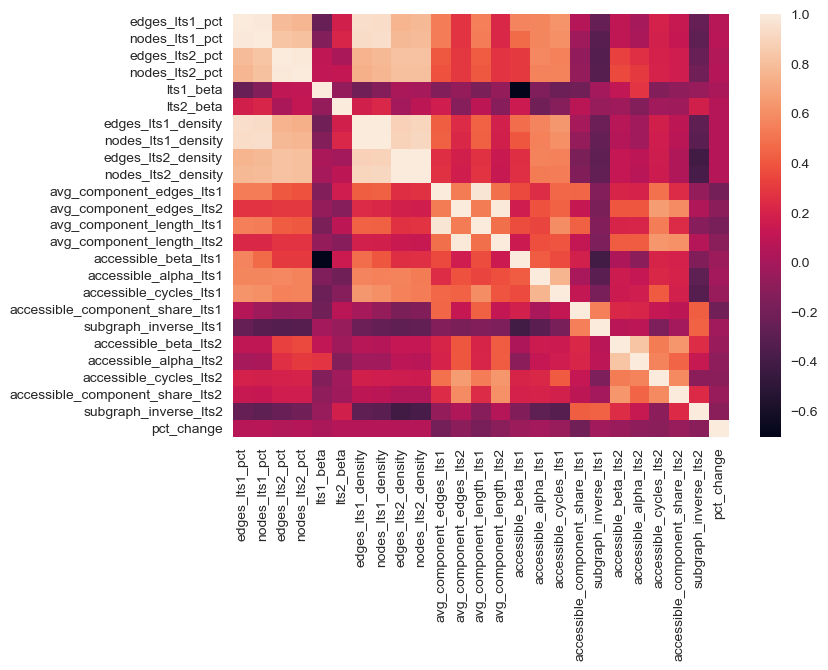

In [20]:
## I think the issue is that they all have too many 0 values
#filter out zero values

## Correlation with percentage change
ridership_quality_combined_nonzero=ridership_quality_combined[ridership_quality_combined[pct_bike_yr2]>0]
correlation=ridership_quality_combined_nonzero[np.append(quality_variable_columns,'pct_change')].corr()
sns.heatmap(correlation)

In [21]:
#highest correlation with percentage change
correlation['pct_change'].sort_values()

accessible_component_share_lts1   -0.218685
avg_component_edges_lts1          -0.198174
avg_component_length_lts1         -0.184445
accessible_cycles_lts2            -0.114631
subgraph_inverse_lts2             -0.113844
avg_component_length_lts2         -0.113388
avg_component_edges_lts2          -0.112900
accessible_alpha_lts2             -0.098724
accessible_component_share_lts2   -0.059009
accessible_cycles_lts1            -0.056278
accessible_beta_lts2              -0.050390
accessible_beta_lts1              -0.043423
subgraph_inverse_lts1             -0.021791
accessible_alpha_lts1             -0.013139
lts1_beta                          0.007598
edges_lts2_pct                     0.046666
edges_lts1_density                 0.051842
edges_lts2_density                 0.053211
nodes_lts1_density                 0.055937
nodes_lts2_pct                     0.056931
lts2_beta                          0.058693
nodes_lts2_density                 0.059673
edges_lts1_pct                  

In [22]:
#sns.pairplot(ridership_quality_combined_nonzero[np.append(quality_variable_columns,'pct_change')])

In [23]:
## table of highest correlation with current ridership?
correlation_2=ridership_quality_combined_nonzero[np.append(quality_variable_columns,pct_bike_yr2)].corr()
correlation_2[pct_bike_yr2].sort_values()

accessible_alpha_lts2             -0.086755
accessible_cycles_lts2            -0.065584
accessible_alpha_lts1             -0.058889
accessible_component_share_lts1   -0.056721
accessible_cycles_lts1            -0.052038
subgraph_inverse_lts2             -0.032918
accessible_beta_lts2              -0.023271
avg_component_length_lts2         -0.015903
accessible_component_share_lts2   -0.007601
avg_component_edges_lts2           0.003655
accessible_beta_lts1               0.005727
lts1_beta                          0.013950
subgraph_inverse_lts1              0.015016
avg_component_length_lts1          0.028450
edges_lts2_density                 0.033913
nodes_lts2_density                 0.039261
nodes_lts2_pct                     0.057593
avg_component_edges_lts1           0.060616
edges_lts2_pct                     0.061689
nodes_lts1_density                 0.082081
edges_lts1_density                 0.082972
lts2_beta                          0.083259
nodes_lts1_pct                  

Text(0.5, 0, 'network quality metric: accessible_beta_lts1')

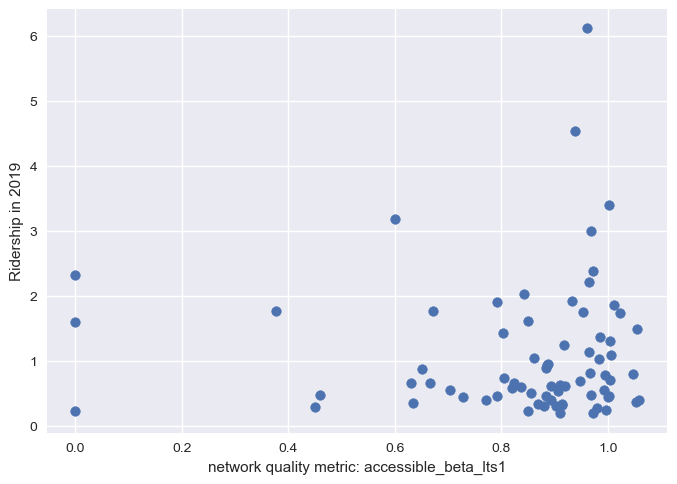

In [34]:
X=ridership_quality_combined_nonzero[quality_variable_columns]
Y=ridership_quality_combined_nonzero[[pct_bike_yr2,'pct_change']]
variable_to_use='accessible_beta_lts1' ## CHANGE THIS TO TRY OTHER QUALITY VARIABLES
plt.scatter(X[variable_to_use],Y[pct_bike_yr2])
plt.ylabel('Ridership in %s'%YEARS[1])
plt.xlabel('network quality metric: %s'%variable_to_use)

Text(0.5, 0, 'network quality metric: accessible_beta_lts1')

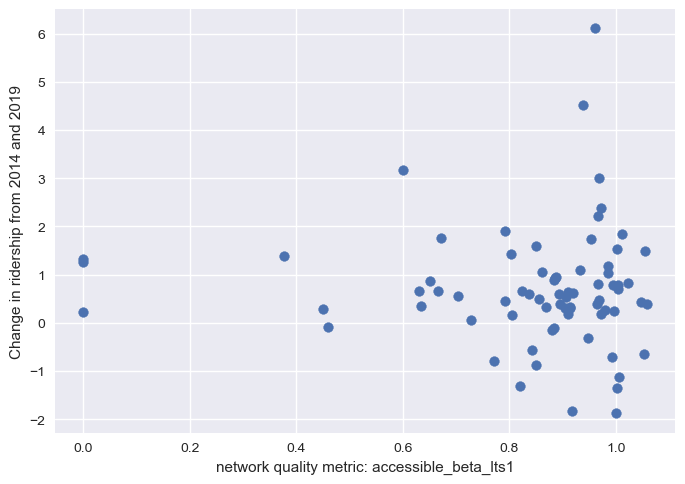

In [25]:
plt.scatter(X[variable_to_use],Y['pct_change'])
plt.ylabel('Change in ridership from %s and %s'%(YEARS[0],YEARS[1]))
plt.xlabel('network quality metric: %s'%variable_to_use)

## 5. Scatter plot: betweenness centrality vs. bike commute share

This plot shows each tract's mean bike-network centrality against the percentage of workers commuting by bicycle.

In [26]:
# fig, ax = plt.subplots(figsize=(10, 6))
# for year, group in tracts.groupby("year"):
#     group = group.dropna(subset=["betweenness", "pct_bike"])
#     ax.scatter(
#         group["betweenness"],
#         group["pct_bike"],
#         alpha=0.75,
#         s=60,
#         label=str(year)
#     )

# ax.set_xlabel("Mean Bike-Network Betweenness Centrality (tract)")
# ax.set_ylabel("% Workers Commuting by Bicycle")
# ax.set_title("Berkeley Census Tracts: Bike Commute Share vs. Bike Network Betweenness")
# ax.legend(title="ACS Year")
# ax.grid(True, linestyle=':', alpha=0.5)
# plt.tight_layout()
# plt.show()

In [27]:
#range = len(group.dropna(subset=["pct_bike"]))

Replace QUALITY_METRIC with correct label

KeyError: 'year'

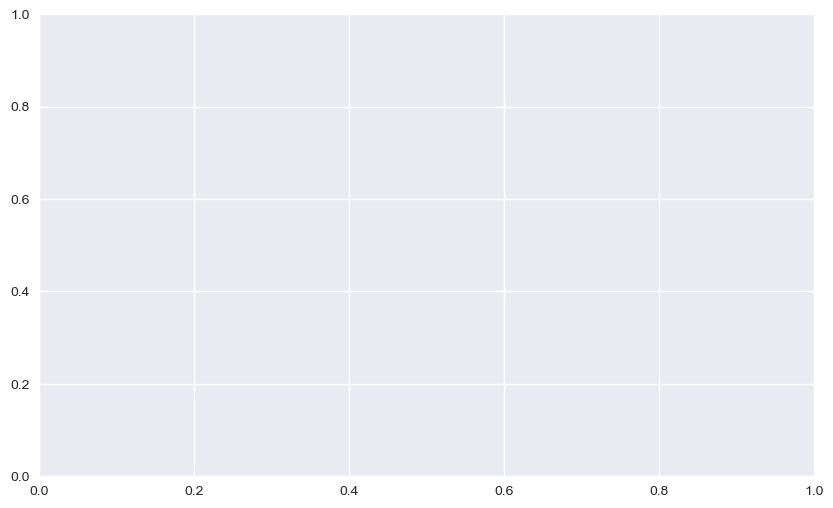

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
for year, group in tracts.groupby("year"):
    group = group.dropna(subset=["QUALITY_METRIC", "pct_bike"])
    ax.scatter(
        group["QUALITY_METRIC"],
        group["pct_bike"],
        alpha=0.75,
        s=60,
        label=str(year)
    )

ax.set_xlabel("Bike Network Quality (LCC for LTS < 2 subnetwork)")
ax.set_ylabel("% Workers Commuting by Bicycle")
ax.set_title("Berkeley Census Tracts: Bike Commute Share vs. Bike Network Quality")
ax.legend(title="ACS Year")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()